In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, RZXGate, XXPlusYYGate, iSwapGate
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_synthesis import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

### Usage as a Decomposer

In [3]:
gate_set = [
    CXGate(),
    CXGate().power(1 / 2),
    iSwapGate().power(1 / 2),
    iSwapGate().power(1 / 3),
]

costs = [1.0, 1 / 2, 1 / 2, 1 / 3]
decomposer = GulpsDecomposer(gate_set, costs)

In [4]:
decomposer = GulpsDecomposer(gate_set, costs, precompute_polytopes=False)

In [5]:
N = 100
# for _ in tqdm(range(N)):
for idx in range(N):
    u = random_unitary(4, seed=2)
    v = Operator(decomposer(u))
    print(average_gate_fidelity(u, v))
    print(c1c2c3(u), c1c2c3(v))
    print("\n")
qc = decomposer(u)
qc.draw()

/home/evm9/hetero_isas/src/gulps/utils/invariants.py:150: UserWarning: Possible sign difference in c parameter during local equivalence recovery.
  warnings.warn(


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)




global phase: 0.94483
     ┌─────────┐┌──────────────────┐  ┌──────────────────────────┐ »
q_0: ┤ Unitary ├┤0                 ├──┤ Rv(1.0787,1.6839,2.8748) ├─»
     ├─────────┤│  (XX+YY)(-π/3,0) │┌─┴──────────────────────────┴┐»
q_1: ┤ Unitary ├┤1                 ├┤ Rv(-1.1638,-6.4154,0.97027) ├»
     └─────────┘└──────────────────┘└─────────────────────────────┘»
«     ┌──────────────────┐┌─────────┐
«q_0: ┤0                 ├┤ Unitary ├
«     │  (XX+YY)(-π/3,0) │├─────────┤
«q_1: ┤1                 ├┤ Unitary ├
«     └──────────────────┘└─────────┘

### Usage as a TransformationPass

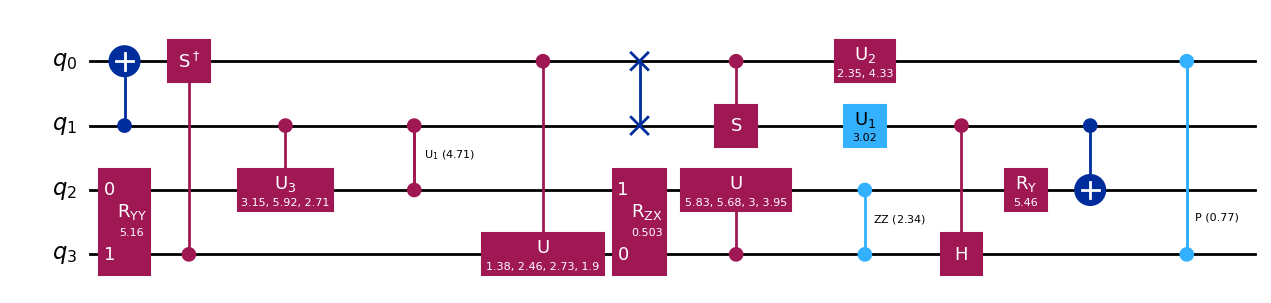

herE
herE
herE
herE
herE
herE
herE
herE
herE
herE
herE
herE
herE
herE


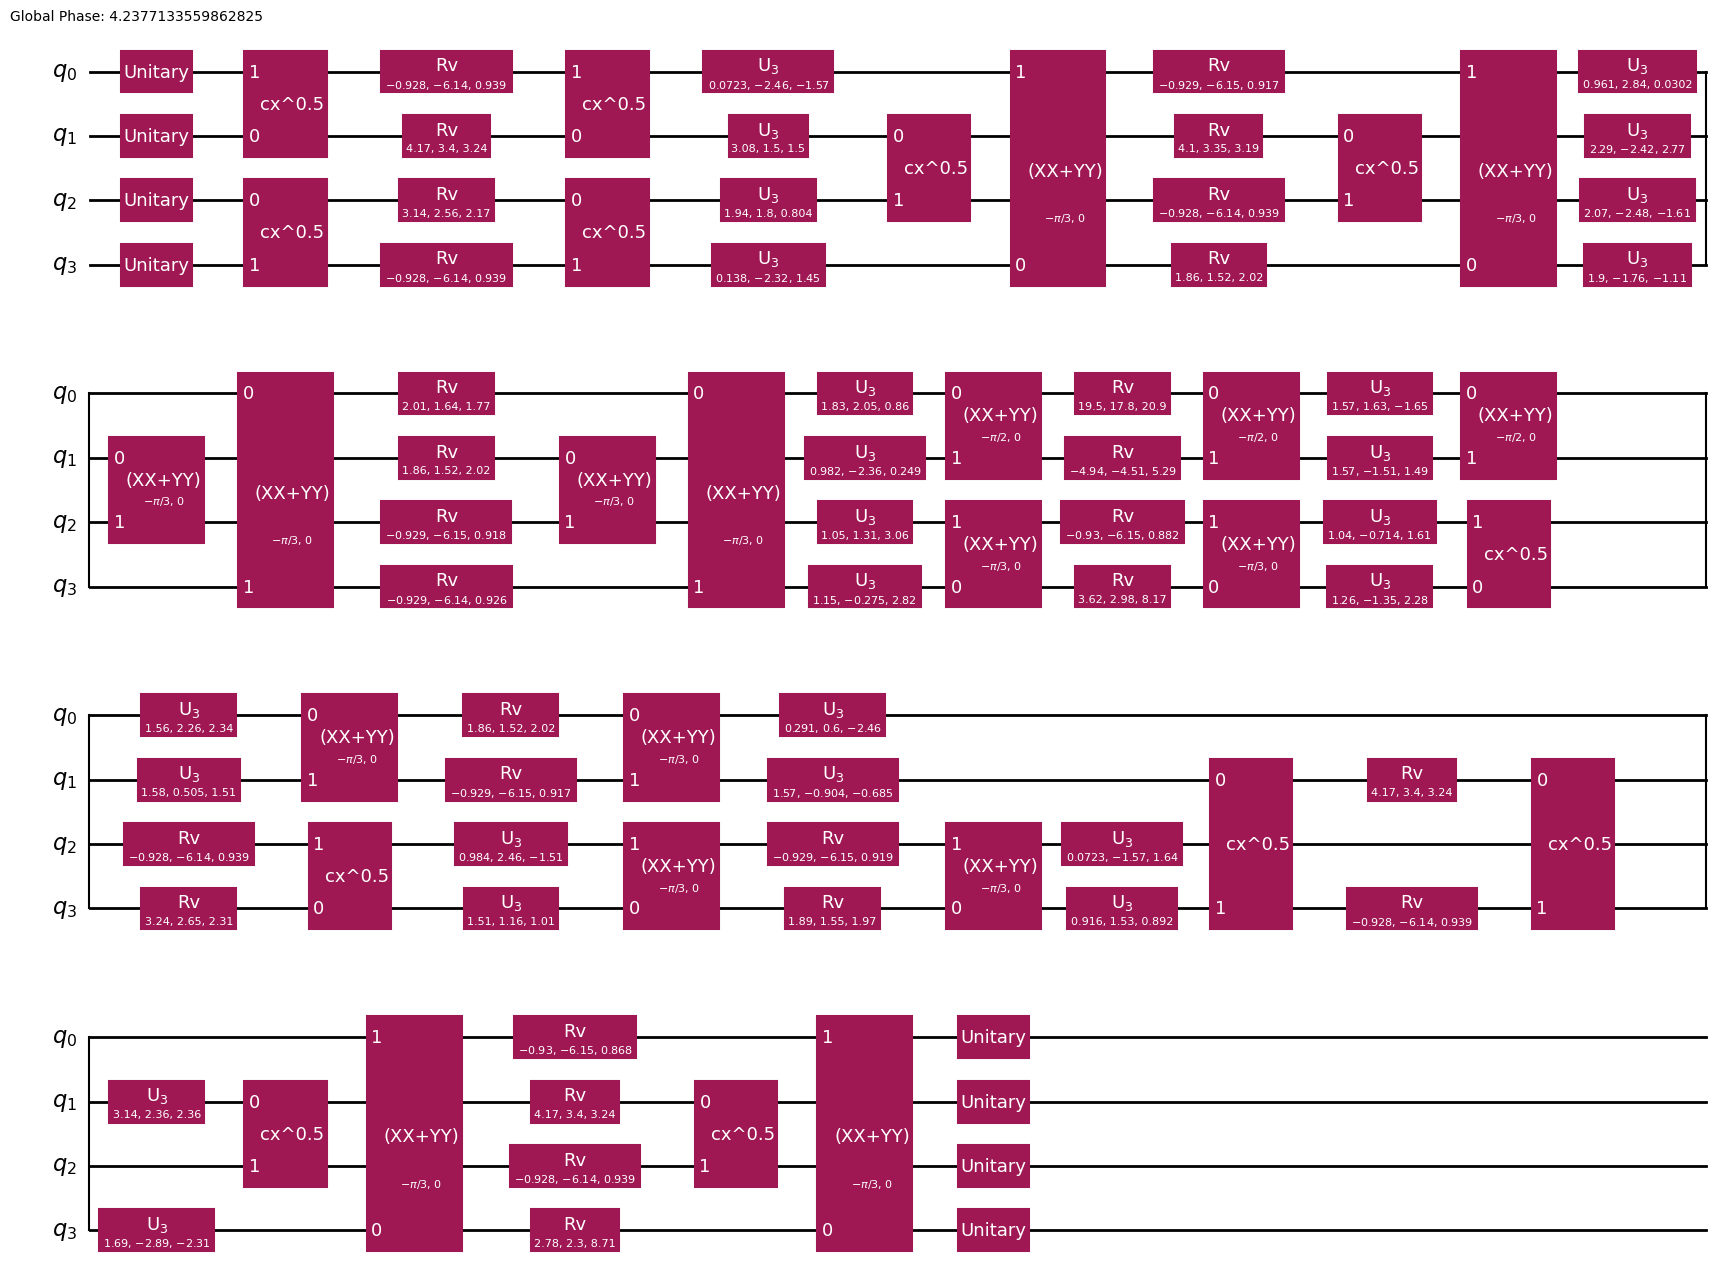

In [6]:
input_qc = random_circuit(
    4, 8, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

pm = PassManager(
    [
        GulpsDecompositionPass(gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl")

### Usage as a Unitary Synthesis Plugin

In [7]:
# check that the plugin is installed
from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

unitary_synthesis_plugin_names()

['gulps', 'aqc', 'clifford', 'default', 'sk']

In [8]:
# create some mock hetereogeneous ISA backend
target = Target()

target.add_instruction(
    RZXGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="cx",
)
target.add_instruction(
    RZXGate(np.pi / 4),
    {
        (0, 1): InstructionProperties(
            duration=50,
            error=0.05,
        )
    },
    name="scx",
)

target.add_instruction(
    XXPlusYYGate(np.pi),
    {
        (0, 1): InstructionProperties(
            duration=200,
            error=0.02,
        )
    },
    name="iswap",
)
target.add_instruction(
    XXPlusYYGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="siswap",
)

In [9]:
target.instructions

[(Instruction(name='rzx', num_qubits=2, num_clbits=0, params=[1.5707963267948966]),
  (0, 1)),
 (Instruction(name='rzx', num_qubits=2, num_clbits=0, params=[0.7853981633974483]),
  (0, 1)),
 (Instruction(name='xx_plus_yy', num_qubits=2, num_clbits=0, params=[3.141592653589793, 0]),
  (0, 1)),
 (Instruction(name='xx_plus_yy', num_qubits=2, num_clbits=0, params=[1.5707963267948966, 0]),
  (0, 1))]

In [10]:
# check that the plugin is installed
from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

unitary_synthesis_plugin_names()

['gulps', 'aqc', 'clifford', 'default', 'sk']

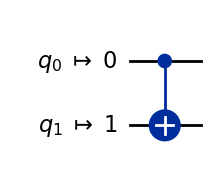

In [11]:
circuit = QuantumCircuit(2)
circuit.cx(0, 1)

pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    target=target,
    unitary_synthesis_method="gulps",
    # unitary_synthesis_plugin_config=dict(basis_gates=["cx", "scx", "iswap", "siswap"]),
)

out = pass_manager.run(circuit)
out.draw("mpl")